In [ ]:
# --- plot_revision setup (auto-injected) ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


/datadrive/fangtq/HiC-DNA


In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tangermeme.plot import plot_logo
from tangermeme.io import read_meme
import seaborn as sns
from plot.plot_utils import _p_to_stars
from plot.plot_settings import colors
from scipy.stats import norm, fisher_exact
from statsmodels.stats.multitest import multipletests


plt.style.use('seaborn-v0_8-white')


In [61]:
# --- 总图：A4 宽度，按你三块内容的相对高度分配 ---
fig = plt.figure(figsize=(8.27, 10))  # 高度可按需要调
outer = fig.add_gridspec(
    3, 1,
    height_ratios=[2.0, 5.0, 2.5],   # 三块纵向比例，对应你三个小节
    hspace=0.3                     # 三块之间的垂直间距
)


# 在 block3_axes 上绘制各自的内容
# e.g. block3_axes[0][0].imshow(...)

# 可选：统一外边距
fig.tight_layout()
plt.show()


<Figure size 827x1000 with 0 Axes>

In [62]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
mpl.rcParams.update({'pdf.fonttype': 42})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])

xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


/home/hanwen/miniconda3/envs/hicdna/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_1370935/2206691310.py:211: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1370935/2206691310.py:263: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1370935/2206691310.py:211: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1370935/2206691310.py:263: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1370935/2206691310.py:211: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1370935/2206691310.py:263: UserW

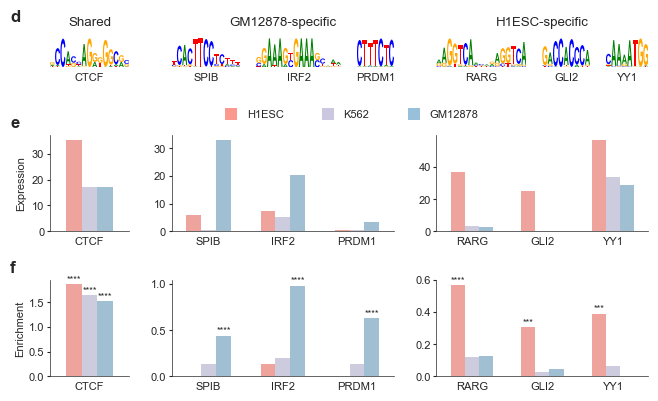

In [63]:
motif2name = {
    'CTCF' : 'CTCF_MA0139.1',
    'NFKB1' : 'NFKB1_MA0105.4',
    'STAT1+STAT2': 'STAT1+STAT2_MA0517.1',
    'SPIB' : 'SPIB_MA0081.1',
    'SPI1' : 'SPI1_MA0080.4',
    'IRF2' : 'IRF2_MA0051.1',
    'PRDM1' : 'PRDM1_MA0508.2',
    'RARG' : 'RARG_nuclearreceptor_6',
    'YY1' : 'YY1_MA0095.2',
    'YY2': 'YY2_MA0748.1',
    'GLI2': 'GLI2_MA0734.1',
    'HIC2': 'HIC2_MA0738.1'
}
motifFull_to_gene = {
    'CTCF_MA0139.1': 'CTCF',
    'STAT1+STAT2_MA0517.1': 'STAT1+STAT2',
    'NFKB1_MA0105.4': 'NFKB1',
    'SPIB_MA0081.1': 'SPIB',
    'SPI1_MA0080.4': 'SPI1',
    'IRF2_MA0051.1': 'IRF2',
    'PRDM1_MA0508.2': 'PRDM1',
    'RARG_nuclearreceptor_6': 'RARG',
    'YY1_MA0095.2': 'YY1',
    'YY2_MA0748.1' : 'YY2',
    'GLI2_MA0734.1': 'GLI2',
    'HIC2_MA0738.1': 'HIC2'

}
cell_order_all = ['H1ESC', 'K562', 'GM12878']
pfm_dict = read_meme(str(MOTIF_MEME))
new_dict = {}
for k,v in pfm_dict.items():
    new_dict[k.split('_')[0].split('.')[0]]=v

def _full_id(name: str) -> str:
    name = str(name).strip()
    if ("MA" in name) or (name in motif2name.values()):
        return name
    return motif2name.get(name, name)

def get_pwm(full_id: str):
    pwm = new_dict.get(full_id.split('_')[1].split('.')[0], None)
    if pwm is None:
        pwm = new_dict.get(full_id.split('_')[0].split('.')[0], None)
    return pwm

def get_motif_len(full_id: str) -> int:
    pwm = get_pwm(full_id)
    return pwm.shape[1]

def _draw_logo(ax, full_id: str):
    ax.set_xticks([]); ax.set_yticks([])

    pwm = get_pwm(full_id)

    h = (pwm * ((pwm+1e-10).log2() - np.log2(0.25))).sum(dim=0)

    plot_logo(pwm*h.unsqueeze(0), ax=ax)

def _tpm_wide_to_long(tpm_wide: pd.DataFrame) -> pd.DataFrame:
    tpm_cols = [c for c in tpm_wide.columns if c.endswith('_TPM')]
    long = tpm_wide[['gene_name'] + tpm_cols].melt(
        id_vars=['gene_name'], value_vars=tpm_cols,
        var_name='cell_raw', value_name='tpm'
    )
    long['cell_line'] = long['cell_raw'].str.replace(r'_TPM$', '', regex=True)
    long = long.rename(columns={'gene_name':'gene'})
    return long[['gene','cell_line','tpm',]]

def _compute_fe(enrich_df: pd.DataFrame) -> pd.DataFrame:
    df = enrich_df.copy()
    df['k0'] = df['k0'].astype(float); df['n0'] = df['n0'].astype(float)
    df['k1'] = df['k1'].astype(float); df['n1'] = df['n1'].astype(float)
    eps = 1e-12
    df['fold_enrichment'] = (df['k0']/(df['n0']+eps)) / (df['k1']/(df['n1']+eps) + eps)
    df['log_fold_enrichment'] = np.log((df['k0']/(df['n0']+eps)) / (df['k1']/(df['n1']+eps) + eps))
    df['motif_name'] = df['motif_name'].map(_full_id)
    cols = ['motif_name','cell_line','fold_enrichment', 'log_fold_enrichment']
    if 'p' in df.columns: cols.append('p')
    if 'q' in df.columns: cols.append('q')
    if 'k0' in df.columns: cols.append('k0')
    return df[cols]

def plot_motif_logo_fe_tpm(enrich_df, tpm_wide, motifs, group_titles):
    if len(motifs) > 0 and isinstance(motifs[0], (list, tuple)):
        groups = [tuple(g) for g in motifs]
    else:
        groups = [ (m,) for m in motifs ]

    fe = _compute_fe(enrich_df)
    tpm_long = _tpm_wide_to_long(tpm_wide)

    n = sum(len(g) for g in groups)

    all_motifs = []
    for g in groups:
        all_motifs.extend(g)

    width_ratios = []
    effective_columns = []
    for g in groups:
        width_ratios.append(5)
        for motif in g:
            full_id = _full_id(motif)
            L = get_motif_len(full_id)
            width_ratios.append(max(1, int(L)))
            effective_columns.append(len(width_ratios)-1)
            width_ratios.append(3)

    # fig = plt.figure(figsize=(8.27, 4.0))
    # gs = fig.add_gridspec(
    #     5, len(width_ratios),
    #     height_ratios=[0.3, 0.7, 1.0, 0.5, 1.0],
    #     width_ratios=width_ratios, \
    #     hspace=0, wspace=0
    # )

    # axes_top = np.empty(n, dtype=object)
    # axes = np.empty((2, len(groups)), dtype=object)

    # for j in range(n):
    #     ax = fig.add_subplot(gs[0, effective_columns[j]]); axes_top[j] = ax
    #     ax.set_aspect('auto')
    #     for s in ax.spines.values(): s.set_linewidth(0.5)

    # for i, p in enumerate([2, 4]):
    #     q = 0
    #     for j, g in enumerate(groups):
    #         ax = fig.add_subplot(gs[p, effective_columns[q]:effective_columns[q+len(g)-1]+1]); axes[i, j] = ax
    #         q += len(g)
    #         ax.set_aspect('auto')
    #         for s in ax.spines.values(): s.set_linewidth(0.5)
    # =============================================================
    # Block 2：原来的 5 行、len(width_ratios) 列的复杂网格（含顶行与两行大面板）
    # =============================================================
    gs2 = outer[1].subgridspec(
        5, len(width_ratios),
        height_ratios=[0.3, 0.7, 1.0, 0.5, 1.0],
        width_ratios=width_ratios,
        hspace=0, wspace=0
    )

    # 顶行轴
    axes_top_b2 = np.empty(n, dtype=object)
    for j in range(n):
        ax = fig.add_subplot(gs2[0, effective_columns[j]])
        axes_top_b2[j] = ax
        ax.set_aspect('auto')
        for s_ in ax.spines.values():
            s_.set_linewidth(0.5)

    # 两行大面板（你原来 i∈{2,4} 的那两行）
    axes_blocks_b2 = np.empty((2, len(groups)), dtype=object)
    for i_idx, p in enumerate([2, 4]):
        q = 0
        for j_idx, g in enumerate(groups):
            # 注意列跨度：effective_columns[q] 到 effective_columns[q+len(g)-1]
            ax = fig.add_subplot(gs2[p, effective_columns[q]:effective_columns[q+len(g)-1]+1])
            axes_blocks_b2[i_idx, j_idx] = ax
            q += len(g)
            ax.set_aspect('auto')
            for s_ in ax.spines.values():
                s_.set_linewidth(0.5)

    for j, motif in enumerate(all_motifs):
        _draw_logo(axes_top_b2[j], _full_id(motif))
        axes_top_b2[j].set_xlabel(motif)

    start = 0
    for j, g in enumerate(groups):
        if len(g) == 0:
            continue
        first = start
        last  = start + len(g) - 1
        start += len(g)

        ax_left  = axes_top_b2[first]
        ax_right = axes_top_b2[last]

        # 取这两个轴在 figure 坐标中的 bbox
        posL = ax_left.get_position()
        posR = ax_right.get_position()

        # group 的水平中心（左右边界的中点）
        cx = (posL.x0 + posR.x1) / 2.0
        # 标题放在该 group 顶边稍上方
        cy = max(posL.y1, posR.y1) + 0.01

        fig.text(
            cx, cy, str(group_titles[j]),
            ha='center', va='bottom',
            fontsize='large'
        )

    palette = colors

    for j, group in enumerate(groups):
        full_ids = [_full_id(m) for m in group]
        shorts = [fid.split('_')[0] for fid in full_ids]

        sub_e = fe[fe['motif_name'].isin(full_ids)].copy()
        name_map = {fid: short for fid, short in zip(full_ids, shorts)}
        sub_e['motif'] = sub_e['motif_name'].map(name_map)

        sub_e = sub_e[sub_e['cell_line'].isin(cell_order_all)]
        sub_e['cell_line'] = pd.Categorical(sub_e['cell_line'], cell_order_all, ordered=True)
        sub_e['motif'] = pd.Categorical(sub_e['motif'], shorts, ordered=True)

        ax1 = axes_blocks_b2[1, j]
        sns.barplot(
            data=sub_e, x='motif', y='log_fold_enrichment',
            hue='cell_line', hue_order=cell_order_all,
            palette=palette, ax=ax1, edgecolor='0.3', linewidth=0, alpha=0.8, width=0.6
        )
        sns.despine(ax=ax1)
        ax1.set_xlabel(''); ax1.set_ylabel('')
        ax1.tick_params(axis='y', labelsize=8, length=2, pad=2)
        # ax1.axhline(0.0, linestyle='--', linewidth=1, color='0.5')
        ax1.set_ylim(bottom=0)
        if j==0:
            ax1.set_ylabel('Enrichment')
            ax1.yaxis.labelpad -= 1

        if 'q' in sub_e.columns:
            p_lookup = {(r['motif'], str(r['cell_line'])): float(r['q']) for _, r in sub_e.iterrows()}
            y0, y1 = ax1.get_ylim()
            dy = (y1 - y0) * 0.01

            patch_idx = 0
            for cell in cell_order_all:
                for m in shorts:
                    if patch_idx >= len(ax1.patches):
                        break
                    patch = ax1.patches[patch_idx]
                    patch_idx += 1
                    pval = p_lookup.get((m, str(cell)), np.nan)
                    stars = _p_to_stars(pval)
                    if stars == 'n.s.': continue
                    if stars:
                        x = patch.get_x() + patch.get_width()/2.0
                        y = patch.get_height()
                        ax1.text(x, y + dy, stars, ha='center', va='bottom', fontsize='small')

        rows = []
        for fid, m_short in zip(full_ids, shorts):
            gene = motifFull_to_gene.get(fid, m_short.upper())
            sub_t = tpm_long[tpm_long['gene'].str.upper() == gene.upper()].copy()
            sub_t = sub_t[sub_t['cell_line'].isin(cell_order_all)]
            if not sub_t.empty:
                sub_t = sub_t[['cell_line', 'tpm']].copy()
                sub_t['motif'] = m_short
                rows.append(sub_t)

        if rows:
            plot_t = pd.concat(rows, axis=0, ignore_index=True)
            plot_t['cell_line'] = pd.Categorical(plot_t['cell_line'], cell_order_all, ordered=True)
            plot_t['motif'] = pd.Categorical(plot_t['motif'], shorts, ordered=True)
        else:
            plot_t = pd.DataFrame(columns=['cell_line','tpm','motif'])

        ax2 = axes_blocks_b2[0, j]
        sns.barplot(
            data=plot_t, x='motif', y='tpm',
            hue='cell_line', hue_order=cell_order_all,
            palette=palette, ax=ax2, edgecolor='0.3', linewidth=0,  alpha=0.8, width=0.6
        )
        sns.despine(ax=ax2)
        ax2.set_xlabel(''); ax2.set_ylabel('')
        ax2.tick_params(axis='y', labelsize=8, length=2, pad=2)
        if j==0:
            ax2.set_ylabel('Expression')

        ax1.legend_.remove() if ax1.legend_ else None
        ax2.legend_.remove() if ax2.legend_ else None

    from matplotlib.lines import Line2D
    pos0, pos1 = axes_blocks_b2[0][0].get_position(), axes_blocks_b2[0][-1].get_position()
    x = (pos0.x0+pos1.x1)/2
    y = pos0.y1 + 0.02

    labels = cell_order_all

    if hasattr(fig, "legend_") and fig.legend_ is not None:
        fig.legend_.remove()

    handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
                    markerfacecolor=palette[i], markeredgewidth=0, alpha=0.8,
                    label=m) for i, m in enumerate(labels)]

    fig.legend(
        handles, labels,
        loc='center',
        bbox_to_anchor=(x, y), 
        ncol=len(labels),
        frameon=False,
        fontsize='medium',         
        handletextpad=0.4, 
        columnspacing=3,   
        borderaxespad=0.1
    )

    axes_top_b2[0].text(
            -0.5, 2, f'd',           # 相对位置：左上角内一点
            transform=axes_top_b2[0].transAxes, 
            fontsize=12,
            font='Arial',
            fontweight='bold',                  # 粗体 (Nature风格)
            ha='left', va='top'                 # 对齐方式
        )

    labels = ['e', 'f']
    axs = [ axes_blocks_b2[0][0], axes_blocks_b2[1][0]]

    for ax, label in zip(axs, labels):
        ax.text(
            -0.5, 1.2, f'{label}',           # 相对位置：左上角内一点
            transform=ax.transAxes, 
            fontsize=12,
            font='Arial',
            fontweight='bold',                  # 粗体 (Nature风格)
            ha='left', va='top'                 # 对齐方式
        )
    return fig

motifs_group = [('CTCF',), ('SPIB', 'IRF2', 'PRDM1'), ('RARG', 'GLI2', 'YY1')]
enrich_df = pd.read_csv(str(MOTIF_STATS_CSV), sep="\t")
enrich_df = enrich_df[~enrich_df['motif_name'].str.contains('_MADS')]
enrich_df = enrich_df[
    enrich_df['motif_name'].str.split('_', n=1).str[0].str.isupper()
]
enrich_df['q'] = enrich_df.groupby('cell_line')['p'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
gene_df = pd.read_csv(str(HUMAN_MERGED_CSV))
fig = plot_motif_logo_fe_tpm(enrich_df, gene_df, motifs_group, group_titles=['Shared', 'GM12878-specific', 'H1ESC-specific'])
fig

In [64]:
seq = np.load(str(HUMAN_INTER_DIR / 'GM12878/seq_9.npy'))
print(seq.shape)

(1, 4, 138394717)


In [65]:
id = 2
epi = 'H3K27ac'
attr_files = {
    'GM12878' : fstr(HUMAN_INTER_DIR / 'GM12878/{epi}/attr_9_filled.npy'), 
    'H1ESC'    : fstr(HUMAN_INTER_DIR / 'H1ESC/{epi}/attr_9_filled.npy'),
    'K562'    : fstr(HUMAN_INTER_DIR / 'K562/{epi}/attr_9_filled.npy'),
}

In [66]:
def standardize(v):
    score = np.sum(v, axis=0)
    meansqr = np.sqrt(np.mean(score.astype(float)**2))
    print(meansqr)
    normalized = v / meansqr
    return normalized

attrs_raw = {}
attrs_standardized = {}
for k, v in attr_files.items():
    attrs_raw[k] = np.load(v)[0]
    print(k)
    print(attrs_raw[k].shape)
    print(np.max(attrs_raw[k]))
    print(np.min(attrs_raw[k]))
    attrs_standardized[k] = standardize(attrs_raw[k])
    print(np.max(attrs_standardized[k]))
    print(np.min(attrs_standardized[k]))

GM12878
(4, 133797422)
0.00025468438980169594
-0.0006633202572218635
6.428535242884694e-07
396.1779475092536
-1031.8373193272096
H1ESC
(4, 133797422)
3.6175384593661875e-05
-7.243648724397644e-05
1.5618225055782164e-07
231.62289225861204
-463.7946180520627
K562
(4, 133797422)
0.0001325813209405169
-0.00036808388540521264
3.147610370986665e-07
421.2126194607667
-1169.4073980631576


In [67]:
pred_files = {
    'GM12878' : str(EPI_EVO2HIC_DIR / 'GM12878' / '9.npy'), 
    'H1ESC'    : str(EPI_EVO2HIC_DIR / 'H1ESC' / '9.npy'),
    'K562'    : str(EPI_EVO2HIC_DIR / 'K562' / '9.npy'),
}

In [68]:
preds = {}
for k, v in pred_files.items():
    preds[k] = np.load(v)[id]
    print(k)
    print(preds[k].shape)


GM12878
(69198,)
H1ESC
(69198,)
K562
(69198,)


In [69]:
from dataset.hic_loader import HiC_Loader
hic_loaders = {
   'GM12878': HiC_Loader(fstr(HIC_RAW('4DNFI1UEG1HD')), resolution=5000),
   'H1ESC': HiC_Loader(fstr(HIC_RAW('4DNFIQYQWPF5')), resolution=5000)
}

In [70]:
s,e = 3477412, 3477430+5
L, R = s//2000-5, s//2000+6

hs0, he0, hs1, he1 = 3140000, 3340000, 3340000, 3540000

In [71]:
# fig = plt.figure(figsize=(8.27, 2.5))
# gs = fig.add_gridspec(2, 7, width_ratios=[1, 0.3, 0.6, 0.3, 1, 0.5, 1], wspace=0, hspace=1)

# # === 第一列合并两行 ===
# ax_seq = fig.add_subplot(gs[:, 0])  # ":" 表示跨两行
# subseq = seq[0, :, s:e]
# subseq=np.flip(subseq, axis=[0,1])
# plot_logo(subseq, ax_seq)
# pos = ax_seq.get_position()
# # 参数：(x0, y0, width, height)
# # 将高度缩小一半，同时上下居中
# new_height = pos.height * 0.15
# ax_seq.set_position([pos.x0, pos.y0 + (pos.height - new_height)/2, pos.width, new_height])
# ax_seq.set_xticks([])
# ax_seq.set_yticks([])
# ax_seq.set_xlabel(f'chr9:{s}-{e}(-)')
# ax_seq.set_title('IRF2 motif site')

# # === 其余三列，两行分别对应 cell line ===
# cell_lines = ["GM12878", "H1ESC"]
# cols = ["Hi-C", "Seq + Attribution", "Predicted Epigenomics"]

# axes = []
# for i, cell in enumerate(cell_lines):
#     row_axes = []
#     for j, col in zip([2,4,6], cols):
#         ax = fig.add_subplot(gs[i, j ])
#         for spine in ax.spines.values():
#             spine.set_linewidth(0.5)

#         row_axes.append(ax)
#     axes.append(row_axes)

# =====================================================
# Block 3：原来的 2x7 布局 + 第一列跨两行 + 手动缩短高度
# =====================================================
gs3 = outer[2].subgridspec(2, 7, width_ratios=[1, 0.3, 0.6, 0.3, 1, 0.5, 1], wspace=0, hspace=1)

# 第一列：合并两行
ax_seq_b3 = fig.add_subplot(gs3[:, 0])
subseq = seq[0, :, s:e]
subseq = np.flip(subseq, axis=[0, 1])
plot_logo(subseq, ax_seq_b3)
pos = ax_seq_b3.get_position()
new_height = pos.height * 0.15  # 你原来的 0.15 比例
ax_seq_b3.set_position([pos.x0, pos.y0 + (pos.height - new_height)/2, pos.width, new_height])
ax_seq_b3.set_xticks([])
ax_seq_b3.set_yticks([])
ax_seq_b3.set_xlabel(f'chr9:{s}-{e}(-)')
ax_seq_b3.set_title('IRF2 motif site')

# 其余三列 × 两行
cell_lines = ["GM12878", "H1ESC"]
cols = ["Hi-C", "Seq + Attribution", "Predicted Epigenomics"]
col_idx_map = [2, 4, 6]  # 对应 gs3 的列索引

block3_axes = []  # 注意命名避免与前面冲突
for i_row, cell in enumerate(cell_lines):
    row_axes = []
    for j_col, col_name in zip(col_idx_map, cols):
        ax = fig.add_subplot(gs3[i_row, j_col])
        for sp in ax.spines.values():
            sp.set_linewidth(0.5)
        # ax.set_title(f"{cell} · {col_name}", fontsize=9)  # 需要可加
        row_axes.append(ax)
    block3_axes.append(row_axes)


for i, cell in enumerate(cell_lines):
    ax = block3_axes[i][0]
    mat = hic_loaders[cell].get('chr9', hs0, he0, 0, 'chr9', hs1, he1, 0, norm=True)
    # mat = np.log1p(mat[0])
    # vmin, vmax = 0, np.log1p(200)
    mat = mat[0]
    vmin, vmax = 0, 100
    n = mat.shape[0]
    ax.imshow(mat, cmap='Reds', origin='upper', vmin=vmin, vmax=vmax,
            extent=(0, n, n, 0),     interpolation='none')

    ax.set_xticks([])
    ax.set_yticks([])

    # ax.set_yticks([0, n])
    # ax.set_yticklabels([f'{hs0/1000000}kb', f'{he0/1000000}kb'])
    # ax.set_xticks([0, n])
    # ax.set_xticklabels([f'{hs1/1000000}kb', f'{he1/1000000}kb'])

    if i==0:
        ax.set_title('Loop')
    else:
        ax.set_title('No loop')
    
    if i==1:
        ax.set_xlabel(f'(chr9:{hs0//1000}kb-{he0//1000}kb,\n chr9:{hs1//1000}kb-{he1//1000}kb)')

for i, cell in enumerate(cell_lines):
    ax = block3_axes[i][1]
    attr = attrs_standardized[cell][:, s:e]
    attr=np.flip(attr, axis=[0,1])
    plot_logo(attr, ax)

    pos = ax.get_position()
    # 参数：(x0, y0, width, height)
    # 将高度缩小一半，同时上下居中
    # new_height = pos.height * 0.5
    # ax.set_position([pos.x0, pos.y0, pos.width, new_height])
    ax.set_xticks([])
    ax.set_yticks([])

    ymin, ymax = ax.get_ylim()
    ymax = max(ymax, 5)
    print(ymin, ymax)
    ax.set_ylim(ymin, ymax)

    if i==0:
        ax.set_title('Active binding site')
    else:
        ax.set_title('Inactive binding site')

for i, cell in enumerate(cell_lines):
    ax = block3_axes[i][2]
    ax.plot(range(L*2, R*2, 2), preds[cell][L:R], linewidth=0.3)
    ax.fill_between(
        x=range(L*2, R*2, 2), 
        y1=preds[cell][L:R],
        alpha=0.5
    )
    ax.set_ylim(0, 0.8)
    # ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)

    ax.set_title(f'Predicted {epi}')

    # 取得原始 tick 值
    xticks = ax.get_xticks()
    # 只在有非空 tick 时设置格式化标签
    if len(xticks) > 0:
        if i==0:
            ax.set_xticklabels([f"{int(x)}kb" for x in xticks])
        else:
            ax.set_xticklabels([f"{int(x)}kb" for x in xticks])
        ax.tick_params(length=2)

-7.870388838782052 42.56516280003527
-0.8582698458403801 5


/tmp/ipykernel_1370935/2308053596.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(x)}kb" for x in xticks])
/tmp/ipykernel_1370935/2308053596.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(x)}kb" for x in xticks])


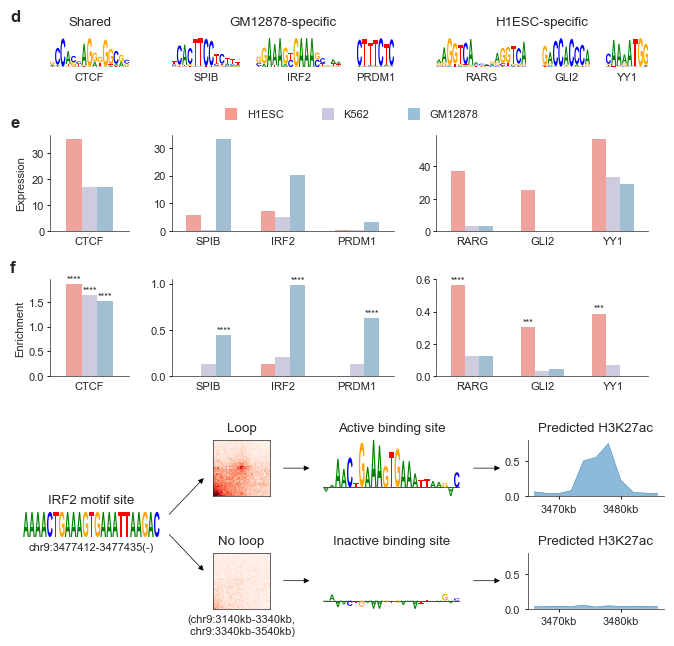

In [72]:
from matplotlib.patches import FancyArrowPatch

# ---- 在 figure 坐标系里画箭头的工具函数 ----
def add_arrow_between(fig, ax_from, ax_to, *,
                      rad=0.0,  # 弧度（0=直线，正/负=微弯）
                      shrinkA=10, shrinkB=10,  # 与起终点的收缩，避免压到坐标轴边
                      lw=0.1):
    # 取两个轴在 figure 坐标中的包围盒
    posA = ax_from.get_position()
    posB = ax_to.get_position()

    # 起点：from 的右侧中点
    xyA = (posA.x1, 0.5 * (posA.y0 + posA.y1))
    # 终点：to 的左侧中点
    xyB = (posB.x0, 0.5 * (posB.y0 + posB.y1))

    arrow = FancyArrowPatch(
        xyA, xyB,
        transform=fig.transFigure,           # 用 figure 坐标
        # connectionstyle=f"arc3,rad={rad}",   # 轻微弯曲更好看，例如 0.05 或 -0.05
        arrowstyle="-|>", linewidth=lw,
        mutation_scale=8, shrinkA=shrinkA, shrinkB=shrinkB,
        zorder=10, clip_on=False, color='black'
    )
    fig.add_artist(arrow)
    return arrow

# ---- 确保位置已稳定后再取坐标 ----
# 如果你用了 constrained_layout/tight_layout，建议先 draw 一次
fig.canvas.draw()

# 第一列（合并的 sequence）连到第二列两行（Hi-C）
ax_hic_row0 = block3_axes[0][0]  # 第0行，第2列（Hi-C）
ax_hic_row1 = block3_axes[1][0]  # 第1行，第2列（Hi-C）

# 从合并的 ax_seq 的右侧中点 -> 两个 Hi-C 轴的左侧中点
add_arrow_between(fig, ax_seq_b3, ax_hic_row0, lw=0.5)
add_arrow_between(fig, ax_seq_b3, ax_hic_row1, lw=0.5)

# 第二列 -> 第三列（每行一条）
for i in range(2):
    add_arrow_between(fig, block3_axes[i][0], block3_axes[i][1], lw=0.5)

# 第三列 -> 第四列（每行一条）
for i in range(2):
    add_arrow_between(fig, block3_axes[i][1], block3_axes[i][2], lw=0.5, shrinkB=20)

fig

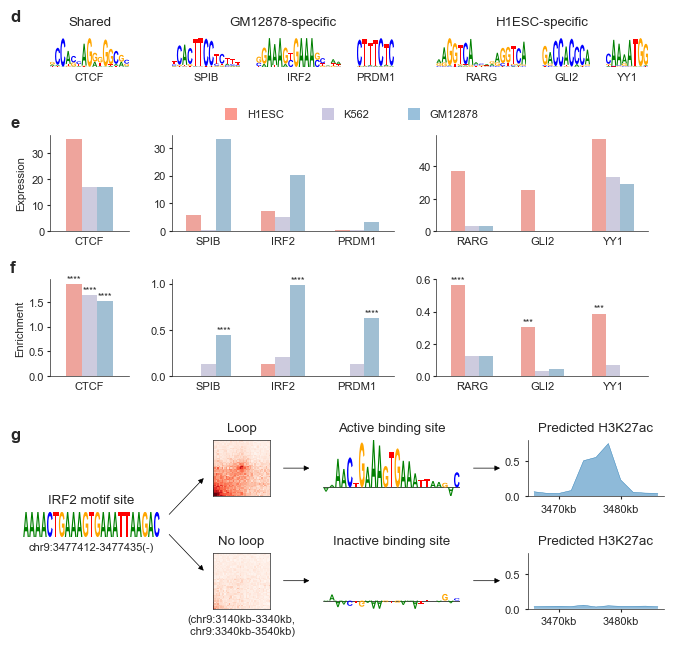

In [73]:
pos = ax_seq_b3.get_position()

# 在 block3 左上角稍微往外一点的位置加字母
fig.text(
    pos.x0 - 0.015,    # 向左微移一点
    pos.y1 + 0.07,    # 在 block3 顶端稍上方
    'g',
    fontsize=12,
    font='Arial',
    fontweight='bold',
    ha='left', va='bottom',
    transform=fig.transFigure
)
fig

In [74]:
# 读取表格
enrich_df = pd.read_csv(str(MOTIF_STATS_CSV), sep="\t")
# enrich_df = enrich_df[enrich_df['motif_name'].str.contains('_MA')]
enrich_df = enrich_df[~enrich_df['motif_name'].str.contains('_MADS')]
enrich_df = enrich_df[
    enrich_df['motif_name'].str.split('_', n=1).str[0].str.isupper()
]
# enrich_pos_df = pd.read_csv(str(REPO / 'result/motif_enrichment_stats_H3K27ac_positive.csv'), sep="\t")
enrich_df['q'] = enrich_df.groupby('cell_line')['p'].transform(lambda x: multipletests(x, method='fdr_bh')[1])

sig_df = enrich_df[(enrich_df["q"] <= 0.05)]

# 获取每个 cell line 的显著 motif 集合
h1 = set(sig_df.loc[sig_df["cell_line"] == "H1ESC", "motif_name"])
k5 = set(sig_df.loc[sig_df["cell_line"] == "K562", "motif_name"])
gm = set(sig_df.loc[sig_df["cell_line"] == "GM12878", "motif_name"])

sig_strict_df = enrich_df[(enrich_df["q"] <= 0.001)  & (enrich_df["k0"] >= 80)]
# sig_strict_df = enrich_df[(enrich_df["q"] <= 0.001)]

# 获取每个 cell line 的显著 motif 集合
h1_s = set(sig_strict_df.loc[sig_strict_df["cell_line"] == "H1ESC", "motif_name"])
k5_s = set(sig_strict_df.loc[sig_strict_df["cell_line"] == "K562", "motif_name"])
gm_s = set(sig_strict_df.loc[sig_strict_df["cell_line"] == "GM12878", "motif_name"])

print(len(h1_s), len(k5_s), len(gm_s))

92 90 107


In [ ]:
# ====== Fig 5f stats summary (motif-enrichment bar plot in plot_motif_logo_fe_tpm) ======
# Test: per-motif z-test on (k0/n0) foreground vs (k1/n1) background.
#   k0 = motif occurrences in high-attribution sites (foreground)
#   n0 = total foreground sites
#   k1 = motif occurrences in genome-wide background
#   n1 = total background sites
# Significance stars in the bar plot use q-values (BH-FDR per cell line).

print("=== Fig 5f motif-enrichment stats ===")
print(f"Test: per-motif z-test (one-sided, foreground vs background)")
print(f"Multiple-testing correction: Benjamini-Hochberg FDR within each cell line")
print()

rows = []
for cell_line, grp in enrich_df.groupby('cell_line'):
    rows.append({
        'cell_line':       cell_line,
        'n_motifs_tested': len(grp),
        'n0_foreground':   int(grp['n0'].iloc[0]),
        'n1_background':   int(grp['n1'].iloc[0]),
        'n_sig_q<=0.05':                len(grp[grp['q'] <= 0.05]),
        'n_sig_q<=0.001':               len(grp[grp['q'] <= 0.001]),
        'n_sig_q<=0.001_AND_k0>=80':    len(grp[(grp['q'] <= 0.001) & (grp['k0'] >= 80)]),
    })
overall = pd.DataFrame(rows)
print("Overall counts per cell line:")
print(overall.to_string(index=False))
overall.to_csv(str(REPO / 'result/Fig5f_enrichment_overall.tsv'), sep='\t', index=False)

# --- Per-motif details for the motifs actually drawn in Fig 5f ---
fig5f_motifs_full = [
    'CTCF_MA0139.1',
    'SPIB_MA0081.1', 'IRF2_MA0051.1', 'PRDM1_MA0508.2',
    'RARG_nuclearreceptor_6', 'GLI2_MA0734.1', 'YY1_MA0095.2',
]
keep = ['cell_line','motif_name','k0','n0','k1','n1','z_stat','p','q']
plotted = enrich_df[enrich_df['motif_name'].isin(fig5f_motifs_full)][keep].copy()
plotted['fold_enrichment'] = (plotted['k0']/plotted['n0']) / (plotted['k1']/plotted['n1'])
plotted['stars'] = plotted['q'].apply(_p_to_stars)
plotted = plotted.sort_values(['motif_name','cell_line']).reset_index(drop=True)

print("\nPer-motif details (the 7 motifs shown in Fig 5f, all 3 cell lines):")
print(plotted.to_string(index=False))
plotted.to_csv(str(REPO / 'result/Fig5f_enrichment_perPlottedMotif.tsv'), sep='\t', index=False)
print(f"\nSaved: result/Fig5f_enrichment_overall.tsv, result/Fig5f_enrichment_perPlottedMotif.tsv")

In [75]:
xlsx_path = "data/dna/motif_annotations.xlsx"   # <- 改成你的xlsx路径
cluster_df = pd.read_excel(xlsx_path, sheet_name="Motifs")  # 表格名叫 motifs
cluster_name_df = pd.read_excel(xlsx_path, sheet_name="Archetype clusters")
cluster_to_name = cluster_name_df.set_index("Cluster_ID")["Name"].to_dict()

motif_to_cluster = dict(zip(cluster_df["Motif"], cluster_df["Cluster_ID"]))
cluster_to_motifs = {}
for motif, cluster in motif_to_cluster.items():
    if cluster not in cluster_to_motifs:
        cluster_to_motifs[cluster] = []
    cluster_to_motifs[cluster].append(motif)

def to_cluster_ids(s:set):
    ids = set()
    for motif in s:
        ids.add(motif_to_cluster[motif])
    return ids

def to_cluster(s:set):
    clusters = {}
    for motif in s:
        id = motif_to_cluster[motif]
        if id not in clusters:
            clusters[id] = []
        clusters[id].append(motif)
    return clusters

In [76]:
def cluster_specific_filter(s0, s1):
    s1c = to_cluster_ids(s1)
    filtered = set()
    for motif in s0:
        if motif_to_cluster[motif] in s1c:
            continue
        filtered.add(motif)
    return filtered
gm_vs_h1 = cluster_specific_filter(gm_s, h1_s)
h1_vs_gm = cluster_specific_filter(h1_s, gm_s)

In [77]:
gm_sp = cluster_specific_filter(gm_vs_h1, k5_s)
gm_vs_h1

{'FOSL2+JUNB_MA1138.1',
 'FOXC1_MA0032.2',
 'FOXC2_MA0846.1',
 'IRF2_MA0051.1',
 'IRF3_MA1418.1',
 'IRF4_MA1419.1',
 'IRF5_MA1420.1',
 'IRF7_MA0772.1',
 'IRF8_MA0652.1',
 'IRF9_MA0653.1',
 'JUNB_MA0490.1',
 'JUND_MA0491.1',
 'MEF2A_MA0052.3',
 'MEF2B_MA0660.1',
 'MEF2C_MA0497.1',
 'MEF2D_MA0773.1',
 'PRDM1_MA0508.2',
 'RELB_MA1117.1',
 'RUNX1_MA0002.2',
 'RUNX2_MA0511.2',
 'RUNX3_MA0684.1',
 'SPI1_MA0080.4',
 'SPIB_MA0081.1',
 'SPIC_MA0687.1'}

In [78]:
h1_sp = cluster_specific_filter(h1_vs_gm, k5_s)
h1_sp

{'GCM1_MA0646.1',
 'HIC2_MA0738.1',
 'RARG_nuclearreceptor_6',
 'SCRT1_MA0743.1',
 'YY1_MA0095.2',
 'YY2_MA0748.1'}

In [79]:
def to_gene(motif:str, split_composite=True):
    shorts = set()
    m = motif.split('_')[0]
    if split_composite and '+' in m:
        m0, m1 = m.split('+')
        shorts.add(m0)
        shorts.add(m1)
    else:
        shorts.add(m)
    return shorts

def calc_gene_foldchange(s, TPMx, TPMy, eps=1e-2):
    print(s)
    log_fold = []
    clusters = []
    for cluster in s:
        gene_set = set()
        if isinstance(s, dict):
            for motif in s[cluster]:
                gene_set.update(to_gene(motif))
        elif isinstance(cluster, int):
            motifs = cluster_df[cluster_df['Cluster_ID']==cluster]['Motif'].to_list()
            for motif in motifs:
                if (motif.isupper() and ('_MA0' in motif or '_MA1' in motif)):
                    gene_set.update(to_gene(motif))
        elif isinstance(cluster, str):
            gene_set = to_gene(cluster)
        else:
            raise NotImplementedError

        if len(gene_set) == 0:
            continue

        gene_sum_x = 0
        gene_sum_y = 0
        gene_mx_x = 0
        gene_mx_y = 0
        for gene in gene_set:
            row = gene_df.loc[gene_df["gene_name"] == gene].squeeze()
            if len(row)==0:
                # print(motif)
                continue
            gene_sum_x += row[TPMx]
            gene_sum_y += row[TPMy]
            gene_mx_x = max(gene_mx_x, row[TPMx])
            gene_mx_y = max(gene_mx_y, row[TPMy])

        # if max(gene_mx_x, gene_mx_y) <1:
        #     continue 
        if gene_sum_x < gene_sum_y or True:
            print(cluster, gene_set, gene_sum_x, gene_sum_y, gene_mx_x, gene_mx_y)
        log_fold.append(np.log((gene_sum_x+eps)/(gene_sum_y+eps)))
        clusters.append(cluster)
    return log_fold, clusters


In [80]:
lf1, c1 = calc_gene_foldchange(to_cluster(gm_vs_h1), 'GM12878_TPM', 'H1ESC_TPM')
lf2, c2 = calc_gene_foldchange(to_cluster(h1_vs_gm), 'H1ESC_TPM', 'GM12878_TPM')


{104: ['IRF9_MA0653.1', 'IRF3_MA1418.1', 'IRF2_MA0051.1', 'IRF7_MA0772.1', 'IRF8_MA0652.1', 'IRF4_MA1419.1'], 95: ['SPIC_MA0687.1', 'SPI1_MA0080.4', 'SPIB_MA0081.1'], 162: ['RELB_MA1117.1'], 183: ['MEF2A_MA0052.3', 'MEF2D_MA0773.1', 'MEF2B_MA0660.1', 'MEF2C_MA0497.1'], 54: ['JUND_MA0491.1', 'FOSL2+JUNB_MA1138.1', 'JUNB_MA0490.1'], 79: ['FOXC2_MA0846.1', 'FOXC1_MA0032.2'], 179: ['RUNX3_MA0684.1', 'RUNX2_MA0511.2', 'RUNX1_MA0002.2'], 103: ['IRF5_MA1420.1'], 105: ['PRDM1_MA0508.2']}
104 {'IRF4', 'IRF2', 'IRF9', 'IRF3', 'IRF7', 'IRF8'} 428.00000000000006 81.84 192.8 61.03
95 {'SPI1', 'SPIC', 'SPIB'} 45.25 5.95 33.12 5.95
162 {'RELB'} 17.07 7.01 17.07 7.01
183 {'MEF2C', 'MEF2A', 'MEF2D', 'MEF2B'} 139.51999999999998 23.38 87.82 12.06
54 {'JUNB', 'JUND', 'FOSL2'} 109.46 47.95 63.8 41.59
79 {'FOXC1', 'FOXC2'} 0.61 0.16999999999999998 0.6 0.12
179 {'RUNX1', 'RUNX2', 'RUNX3'} 65.26 1.41 59.03 0.65
103 {'IRF5'} 29.18 0.15 29.18 0.15
105 {'PRDM1'} 3.27 0.4 3.27 0.4
{45: ['RARG_nuclearreceptor_6'],

In [81]:
lf1_, c1_ = calc_gene_foldchange(to_cluster_ids(gm_s)&to_cluster_ids(h1_s), 'GM12878_TPM', 'H1ESC_TPM')
lf2_, c2_ = calc_gene_foldchange(to_cluster_ids(gm_s)&to_cluster_ids(h1_s), 'H1ESC_TPM', 'GM12878_TPM')

{132, 261, 262, 263, 264, 265, 266, 268, 273, 274, 155, 156, 30, 286, 161, 41, 174, 186, 59, 63, 192, 65, 194, 68, 199, 98, 106, 109, 110, 111, 112, 113, 117}
132 {'THAP1'} 3.6 8.17 3.6 8.17
261 {'GLIS1', 'GLIS3', 'GLIS2'} 0.46 9.959999999999999 0.25 9.34
262 {'GLI2', 'ZBTB7B', 'ZBTB7C'} 17.540000000000003 38.550000000000004 17.5 25.18
263 {'TFAP2A', 'TFAP2B', 'TFAP2C'} 0.21 3.1199999999999997 0.18 3.11
264 {'TFAP2A', 'TFAP2B', 'TFAP2C'} 0.21 3.1199999999999997 0.18 3.11
265 {'CTCFL', 'CTCF'} 17.02 35.85 16.98 35.42
266 {'INSM1'} 0.0 1.36 0 1.36
268 {'PLAG1'} 1.97 7.09 1.97 7.09
273 {'ZIC3', 'ZIC1', 'ZIC4'} 0.01 40.53 0.01 39.27
274 {'HINFP'} 9.56 18.78 9.56 18.78
155 {'ZBTB33'} 6.67 8.01 6.67 8.01
156 {'TFDP1', 'E2F4', 'E2F6'} 119.38 94.86 72.6 43.97
30 {'HNF4G', 'RXRB', 'NR2C2', 'NR1H2', 'RXRG', 'RXRA'} 55.41 71.96000000000001 16.89 23.86
286 {'ZSCAN4'} 0.0 0.0 0 0
161 {'NFKB1', 'NFKB2'} 98.78 14.6 56.07 10.94
41 {'RORA', 'NR4A2', 'NR4A1', 'NR2F2', 'NR2F1', 'RXRA', 'RARA', 'RXRG'} 39

In [82]:
print(c1, c2, lf1, lf2)

[104, 95, 162, 183, 54, 79, 179, 103, 105] [45, 67, 58, 145, 200, 187, 201, 66] [1.6542582559776888, 2.027353159128133, 0.8891449703227042, 1.7859710513080276, 0.8252832089571525, 1.236762627148927, 3.8278756410339567, 5.206407648614333, 2.0794415416798357] [2.56090677009376, 3.7256934272366524, -0.6418538861723948, 0.677485557621957, -0.002163722445310919, 1.7977245486965299, 0.5108256237659907, 2.639057329615259]


/tmp/ipykernel_1370935/2147576315.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="log fold change", data=df1, inner="box", palette=colors, ax=block1_axes[1], cut=0, alpha=0.7, linewidth=0.5)
/tmp/ipykernel_1370935/2147576315.py:20: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.violinplot(x="group", y="log fold change", data=df1, inner="box", palette=colors, ax=block1_axes[1], cut=0, alpha=0.7, linewidth=0.5)
/tmp/ipykernel_1370935/2147576315.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="log fold change", data=df2, inner="box", palette=colors, ax=block1_axes[2], cut=0, alpha=0.7, linewidth=0.

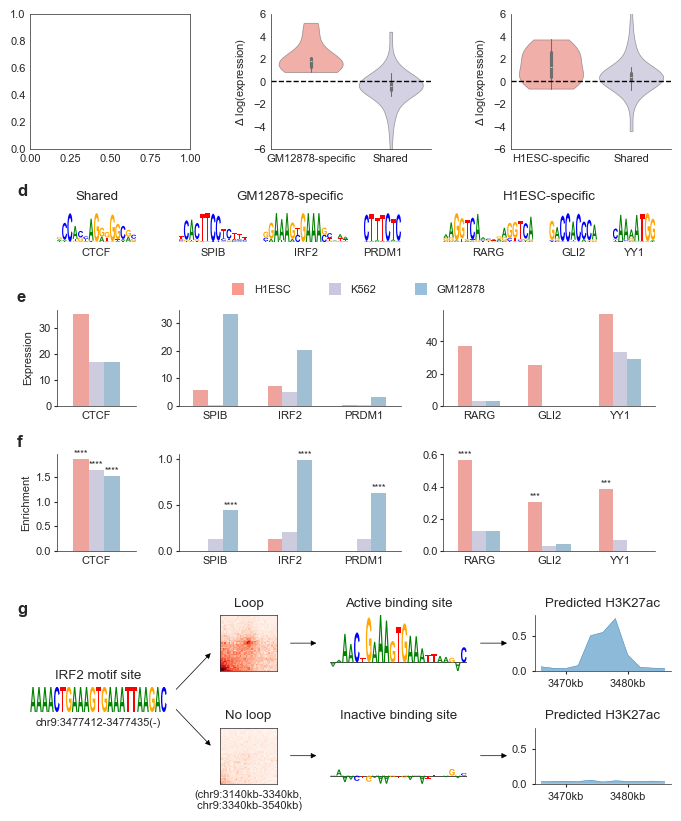

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Block 1：原来的 1x3 布局
# =========================
gs1 = outer[0].subgridspec(1, 3, wspace=0.5)
block1_axes = [fig.add_subplot(gs1[0, j]) for j in range(3)]
# 这里继续画你的 Block1 内容到 block1_axes[0/1/2]
# e.g. block1_axes[0].plot(...)


# 构建DataFrame
df1 = pd.DataFrame({
    "log fold change": lf1 + lf1_,
    "group": ["GM12878-specific"] * len(c1) + ["Shared"] * len(c1_)
})

sns.violinplot(x="group", y="log fold change", data=df1, inner="box", palette=colors, ax=block1_axes[1], cut=0, alpha=0.7, linewidth=0.5)
block1_axes[1].set_ylabel("$\Delta$ log(expression)")
block1_axes[1].set_xlabel("")
block1_axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
block1_axes[1].set_ylim(-6, 6)
sns.despine(ax=block1_axes[1])

# for violin in axes[0].collections:
#     violin.set_edgecolor("none")

df2 = pd.DataFrame({
    "log fold change": lf2 + lf2_,
    "group": ["H1ESC-specific"] * len(c2) + ["Shared"] * len(c2_)
})

sns.violinplot(x="group", y="log fold change", data=df2, inner="box", palette=colors, ax=block1_axes[2], cut=0, alpha=0.7, linewidth=0.5)
block1_axes[2].set_ylabel("$\Delta$ log(expression)")
block1_axes[2].set_xlabel("")
block1_axes[2].axhline(0, color="black", linewidth=1, linestyle="--")
block1_axes[2].set_ylim(-6, 6)
sns.despine(ax=block1_axes[2])

for ax in block1_axes:
    for s in ax.spines.values(): s.set_linewidth(0.5)

fig


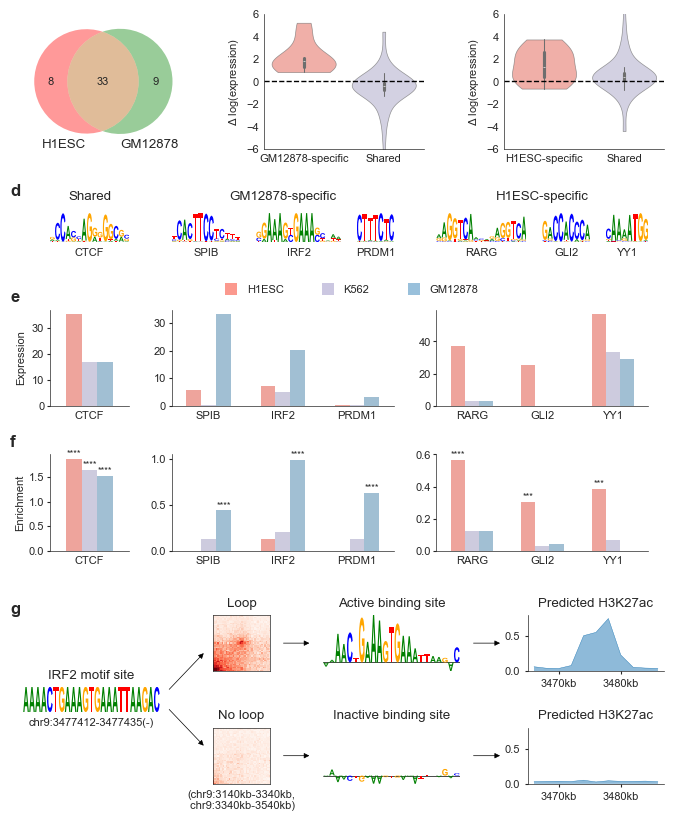

In [84]:
from matplotlib_venn import venn2
from matplotlib_venn.layout.venn2 import DefaultLayoutAlgorithm
class PowerLayoutAlgorithm(DefaultLayoutAlgorithm):
    def __init__(self, power=0.3, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.power=power
    
    def __call__(self, subsets, set_labels = None):
        new_subsets = []
        for n in subsets:
            new_subsets.append(n**self.power)
        return super().__call__(new_subsets, set_labels)

class uniformLayourAlgorithm(DefaultLayoutAlgorithm):
    def __init__(self,*args, **kwargs):
        super().__init__(*args, fixed_subset_sizes=[1,1,1], **kwargs)

block1_axes[0].clear()

venn2([to_cluster_ids(h1_s), to_cluster_ids(gm_s)], set_labels=['H1ESC', 'GM12878'], layout_algorithm=PowerLayoutAlgorithm(0.3), ax=block1_axes[0])
fig

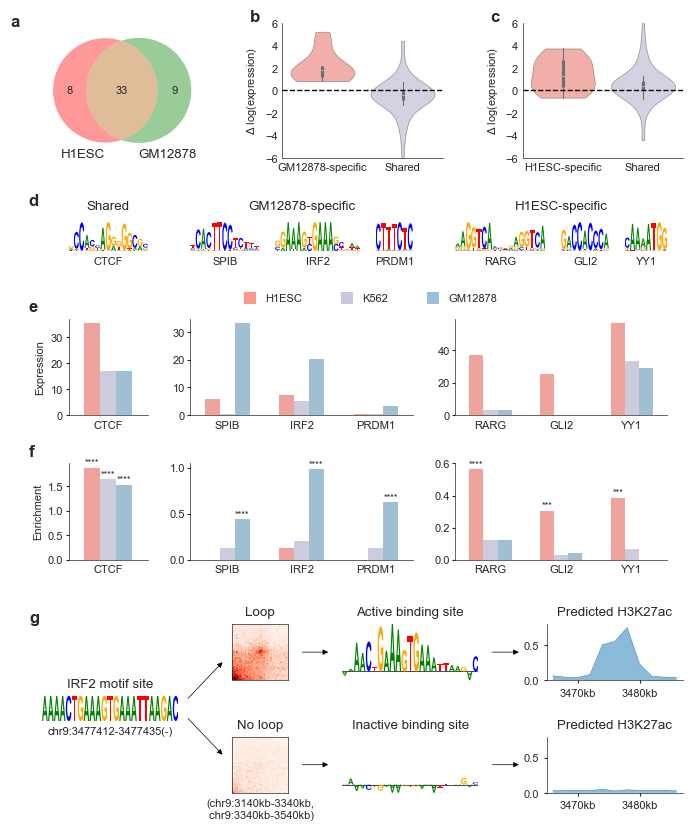

In [85]:
labels = ['a', 'b', 'c']
for ax, label in zip(block1_axes, labels):
    ax.text(
        -0.2, 1.1, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        font='Arial',
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig


In [86]:
fig.savefig(str(OUT_DIR / 'Fig_interpret.pdf'))